# IMPORT LIBRARIES

In [38]:
import pandas as pd #pandas for data manipulation and analysis i.e reading csv files into dataframes
import numpy as np #numpy for numerical operations and handling arrays  
import matplotlib.pyplot as plt #matplotlib for data visualization such as plotting graphs and charts

import seaborn as sns #seaborn for statistical data visualization built on top of matplotlib i.e enhanced plotting capabilities
import sklearn #sklearn for machine learning tasks and algorithms 
from sklearn.model_selection import train_test_split    #train_test_split to split dataset into training and testing sets
from sklearn.ensemble import RandomForestRegressor #RandomForestRegressor for regression tasks using ensemble of decision trees
from sklearn.ensemble import RandomForestClassifier #RandomForestClassifier for classification tasks using ensemble of decision trees   
from sklearn.metrics import classification_report, confusion_matrix #classification_report and confusion_matrix for evaluating classification model performance
from sklearn.preprocessing import StandardScaler, LabelEncoder #StandardScaler for feature scaling and LabelEncoder for encoding categorical labels
from sklearn.metrics import mean_absolute_error, accuracy_score #mean_absolute_error for regression model evaluation and accuracy_score for classification model evaluation


# LOAD DATA

In [ ]:
df = pd.read_csv('india_housing_prices.csv') #reading the dataset into a pandas dataframe

# BASIC DATA EXPLORATION

In [ ]:
df.info() #displaying summary information about the dataframe including data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [ ]:
df.shape #checking the dimensions of the dataframe (number of rows and columns)

(250000, 23)

In [ ]:
df.describe().T #generating descriptive statistics i.e count, mean, std, min, max, and percentiles for numerical columns and transposing for better readability

,count,mean,std,min,25%,50%,75%,max
ID,250000.0,125000.500000,72168.927986,1.0,62500.75,125000.50,187500.25,250000.00
BHK,250000.0,2.999396,1.415521,1.0,2.00,3.00,4.00,5.00
Size_in_SqFt,250000.0,2749.813216,1300.606954,500.0,1623.00,2747.00,3874.00,5000.00
Price_in_Lakhs,250000.0,254.586854,141.349921,10.0,132.55,253.87,376.88,500.00
Price_per_SqFt,250000.0,0.130597,0.130747,0.0,0.05,0.09,0.16,0.99
Year_Built,250000.0,2006.520012,9.808575,1990.0,1998.00,2007.00,2015.00,2023.00
Floor_No,250000.0,14.966800,8.948047,0.0,7.00,15.00,23.00,30.00
Total_Floors,250000.0,15.503004,8.671618,1.0,8.00,15.00,23.00,30.00
Age_of_Property,250000.0,18.479988,9.808575,2.0,10.00,18.00,27.00,35.00
Nearby_Schools,250000.0,5.499860,2.878639,1.0,3.00,5.00,8.00,10.00


In [ ]:
df.describe(include='object').T  #generating descriptive statistics for categorical (object) columns and transposing for better readability

,count,unique,top,freq
State,250000,20,Odisha,12681
City,250000,42,Coimbatore,6461
Locality,250000,500,Locality_296,567
Property_Type,250000,3,Villa,83744
Furnished_Status,250000,3,Unfurnished,83408
Public_Transport_Accessibility,250000,3,High,83705
Parking_Space,250000,2,No,125456
Security,250000,2,Yes,125233
Amenities,250000,325,Pool,10218
Facing,250000,4,West,62757


Checking unique values for key categoricals to reveal class imbalance

In [ ]:
df['Property_Type'].value_counts() #counting occurrences of each unique value in the 'Property_Type' column to understand distribution of property types

Property_Type
Villa                83744
Independent House    83300
Apartment            82956
Name: count, dtype: int64

In [ ]:
df['State'].value_counts() #counting occurrences of each unique value in the 'State' column to understand distribution of properties across states

State
Odisha            12681
Tamil Nadu        12629
West Bengal       12622
Gujarat           12578
Delhi             12552
Telangana         12539
Maharashtra       12533
Punjab            12516
Uttar Pradesh     12508
Uttarakhand       12501
Assam             12496
Kerala            12487
Jharkhand         12480
Andhra Pradesh    12462
Chhattisgarh      12456
Madhya Pradesh    12451
Karnataka         12424
Rajasthan         12402
Bihar             12369
Haryana           12314
Name: count, dtype: int64

# DETECTING AND HANDLING OUTLIERS

IQR METHOD

In [ ]:
#Outliers distort models

Q1 = df['Price_in_Lakhs'].quantile(0.25) #25% of properties cost below this value
Q3 = df['Price_in_Lakhs'].quantile(0.75) #75% of properties cost below this value

IQR = Q3 - Q1 # IQR method for robust detection on skewed features like prices

lower_bound = Q1 - 1.5 * IQR #Anything below this is an outlier
upper_bound = Q3 + 1.5 * IQR #Anything above this is an outlier

In [ ]:
print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"Lower Bound: {lower_bound}") 
print(f"Upper Bound: {upper_bound}")

Q1: 132.55
Q3: 376.88
Lower Bound: -233.945
Upper Bound: 743.375


Check for outlier (One Column)

In [ ]:
is_outlier = (df['Price_in_Lakhs'] < lower_bound) | (df['Price_in_Lakhs'] > upper_bound) #boolean mask for identifying outliers in 'Price_in_Lakhs' column
outliers = df[is_outlier] #dataframe containing only the outlier rows based on 'Price_in_Lakhs' column
print(f"Number of outliers in 'Price_in_Lakhs': {outliers.shape}") #shape gives number of rows that satisfy the condition, total columns

Number of outliers in 'Price_in_Lakhs': (0, 23)


Function to cap outliers for whole dataset

In [ ]:
# Cap extremes at 1st/99th percentiles to preserve data while reducing noise.

def cap_outliers(series, lower = 1, upper = 99): #function to cap outliers in a pandas Series based on specified lower and upper percentiles
    lower_per, upper_perc = series.quantile([lower/100, upper/100]) #calculating the lower and upper percentile values
    return series.clip(lower=lower_per, upper=upper_perc) #capping values below lower_per to lower_per and above upper_perc to upper_perc



In [ ]:
df['Price_in_Lakhs'] = cap_outliers(df['Price_in_Lakhs']) #capping outliers in 'Price_in_Lakhs' column
df['Size_in_SqFt'] = cap_outliers(df['Size_in_SqFt']) #capping outliers in 'Size_in_SqFt' column
df['Price_per_SqFt'] = cap_outliers(df['Price_per_SqFt']) #capping outliers in 'Price_per_SqFt' column

visualise before and after to confirm outlier handling

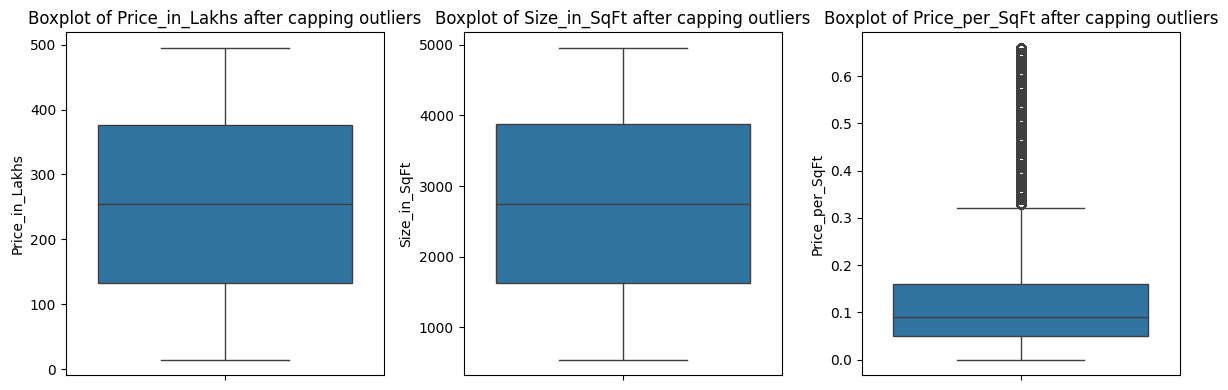

In [ ]:
plt.figure(figsize=(12,4)) # Creates a new blank figure (canvas) - width and height (inches) to place plots

#seaborn for statistical data visualization built on top of matplotlib i.e enhanced plotting capabilities
# plt.subplot(nrows, ncols, index)

plt.subplot(1,3,1); sns.boxplot(df['Price_in_Lakhs']); plt.title('Boxplot of Price_in_Lakhs after capping outliers') #visualizing the effect of outlier capping using boxplots
plt.subplot(1,3,2); sns.boxplot(df['Size_in_SqFt']); plt.title('Boxplot of Size_in_SqFt after capping outliers') #visualizing the effect of outlier capping using boxplots
plt.subplot(1,3,3); sns.boxplot(df['Price_per_SqFt']); plt.title('Boxplot of Price_per_SqFt after capping outliers') #visualizing the effect of outlier capping using boxplots
plt.tight_layout();plt.show() #adjusting layout and displaying the plots

# FEARURE ENGINEERING FOR TARGETS
Future_Price (regression) and Good_Investment (classification)

In [ ]:
growth_rates = { 
    'Odisha': 0.07,
    'Karnataka': 0.06,
    'coimbatore': 0.09,
    'default': 0.08
} #defining growth rates for specific states and a default rate


In [ ]:
# Future Price: Current * (1+r)^5

df['City'] = df['City'].replace({k: v for k, v in growth_rates.items() if k in df['City'].unique()}, regex=True) #mapping growth rates to cities in the dataframe
df['growth_rate'] = df['City'].map(growth_rates).fillna(growth_rates['default']) #assigning growth rates to each property based on its city, using default rate if city not in growth_rates
df['Future_Price'] = df['Price_in_Lakhs'] * (1 + df['growth_rate'])**5 #calculating future price after 5 years using compound interest formula

In [ ]:
# Good Investment (binary): Multi-factor - why? Combines price value + quality signals
median_price_sqft = df.groupby(['City', 'Property_Type'])['Price_per_SqFt'].transform('median') #calculating median Price_per_SqFt for each City and Property_Type combination
df['below_median_price'] = (df['Price_per_SqFt'] <= median_price_sqft).astype(int) #flagging properties below median price as 1, others as 0


In [ ]:
df['quality_score'] = (
    (df['BHK'] >= 3).astype(int) * 0.3 +  # Larger = better investment
    (df['Security'] == 'Yes').astype(int) * 0.2 + # Security presence
    (df['Parking_Space'] != 'No').astype(int) * 0.2 + # Parking availability
    (df['Furnished_Status'] != 'Unfurnished').astype(int) * 0.15 + # Furnished or semi-furnished preferred
    (df['Availability_Status'] == 'Available').astype(int) * 0.15  # Ready-to-move premium
) #calculating a quality score based on multiple factors relevant to investment quality

In [ ]:

df['Good_Investment'] = ((df['below_median_price'] == 1) & (df['quality_score'] >= 0.6)).astype(int) #defining good investment as below median price and quality score >= 0.6
print(df['Good_Investment'].value_counts(normalize=True))  # Check balance (~50% good target) #balanced dataset with roughly equal good and bad investments

Good_Investment
0    0.81838
1    0.18162
Name: proportion, dtype: float64


# ENCODE CATEGORICALS AND SCALE FEATURES

In [ ]:
# Target encoding for high cardinality categorical variables to reduce dimensionality

top_localities = df['Locality'].value_counts().nlargest(10).index #identifying top 10 most frequent localities
df['Locality_grouped'] = df['Locality'].where(df['Locality'].isin(top_localities), 'Other') #grouping less frequent localities into 'Other' category


In [ ]:
# Label encode categorical variables for tree models and one hot for liner models

categorical_cols = ['State', 'City', 'Locality_grouped', 'Property_Type', 'Furnished_Status',
                   'Public_Transport_Accessibility', 'Parking_Space', 'Security', 
                   'Amenities', 'Facing', 'Owner_Type', 'Availability_Status'] #list of categorical columns to be encoded

In [ ]:
le_dict = {} #dictionary to store LabelEncoders for each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str)) #encoding categorical columns using LabelEncoder
    le_dict[col] = le
    #storing the fitted LabelEncoder for future use

In [ ]:
feature_cols = ['State', 'City', 'Locality_grouped', 'Property_Type', 'BHK', 'Size_in_SqFt',
                'Price_per_SqFt', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals',
                'Floor_No', 'Total_Floors', 'Furnished_Status', 'Public_Transport_Accessibility',
                'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status'] #list of feature columns for model training

In [ ]:
X = df[feature_cols] #feature matrix for model training
y_reg = df['Future_Price'] #target variable for regression model
y_clf = df['Good_Investment'] #target variable for classification model

In [ ]:
# Scale numerical - why? Gradient descent converges faster
scaler = StandardScaler() #initializing StandardScaler for feature scaling
num_cols = X.select_dtypes(include=[np.number]).columns #identifying numerical columns in feature matrix
X[num_cols] = scaler.fit_transform(X[num_cols]) #scaling numerical features using StandardScaler

C:\Users\aniru\AppData\Local\Temp\ipykernel_24804\1035227635.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[num_cols] = scaler.fit_transform(X[num_cols])


In [ ]:
# Split - why? Prevents leakage; stratify for imbalanced classification
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.2, random_state=42) #splitting data into training and testing sets for regression model
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(X, y_clf, test_size=0.2, stratify=y_clf, random_state=42) #splitting data into training and testing sets for classification model with stratification

# EDA Visualizations and Insights

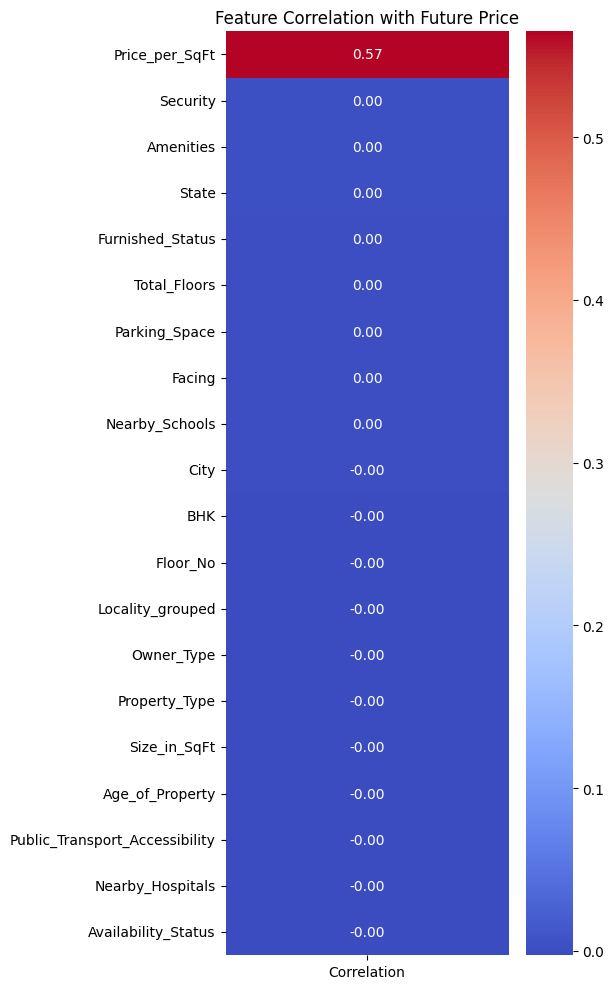

In [ ]:
# Correlation heatmap - to identify multicollinearity (drop Total_Floors if high corr with Floor_No)
# Correlation heatmap - to identify multicollinearity (drop Total_Floors if high corr with Floor_No)

corr_with_target = X.corrwith(y_reg).sort_values(ascending=False).to_frame(name='Correlation') 
#calculating correlation of each feature with the target variable 'Future_Price' and sorting

plt.figure(figsize=(6, 10))   # Taller figure because it's a single column heatmap
sns.heatmap(corr_with_target, annot=True, cmap='coolwarm', cbar=True, fmt=".2f") #plotting heatmap of feature correlations with target variable

plt.title('Feature Correlation with Future Price') #adding title to the heatmap
plt.tight_layout() #adjusting layout
plt.show() #displaying the heatmap


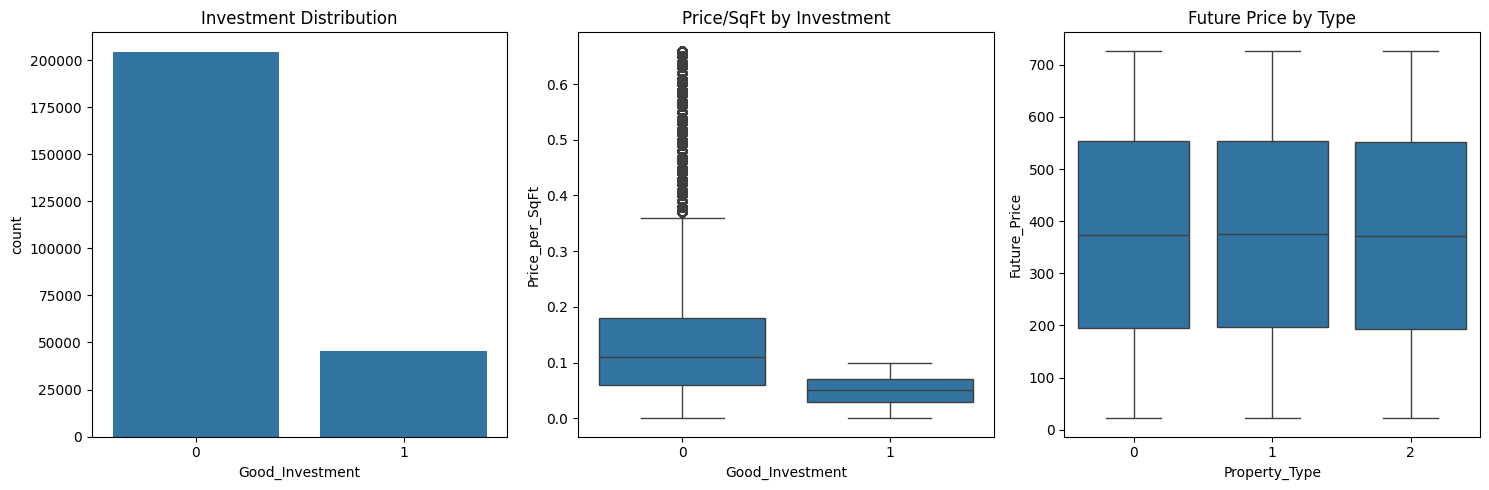

In [ ]:
# Investment quality distribution - why? Confirms good/bad deal logic
fig, axes = plt.subplots(1,3, figsize=(15,5)) #creating subplots for visualizing investment quality distribution
sns.countplot(data=df, x='Good_Investment', ax=axes[0]); axes[0].set_title('Investment Distribution') #countplot of good vs bad investments
sns.boxplot(data=df, x='Good_Investment', y='Price_per_SqFt', ax=axes[1]); axes[1].set_title('Price/SqFt by Investment') #boxplot of Price_per_SqFt by investment quality
sns.boxplot(data=df, x='Property_Type', y='Future_Price', ax=axes[2]); axes[2].set_title('Future Price by Type') #boxplot of Future_Price by Property_Type
plt.tight_layout(); plt.show() #adjusting layout and displaying the plots

In [ ]:
# Save processed data for modeling/Streamlit
df.to_csv('processed_property_data.csv', index=False) #saving the cleaned and processed dataframe to a new CSV file for future use
print("Data cleaned and ready! Shape:", X.shape, "\n Regression target mean:", y_reg.mean()) #printing confirmation message with shape of feature matrix and mean of regression target variable

Data cleaned and ready! Shape: (250000, 20) 
 Regression target mean: 374.06964960284506


# SPLIT DATA INTO TRAINING AND TESTING 

In [ ]:
# Split for PRICE prediction 
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
) #splitting data into training and testing sets for regression model

In [ ]:
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, stratify=y_clf, random_state=42
) #splitting data into training and testing sets for classification model with stratification

In [ ]:
print("✅ Training data ready!")
print("Regression training:", X_reg_train.shape) #printing shape of regression training feature matrix
print("Classification training:", X_clf_train.shape) #printing shape of classification training feature matrix

✅ Training data ready!
Regression training: (200000, 20)
Classification training: (200000, 20)


# BUILD PRICE MODEL

In [ ]:
price_model = RandomForestRegressor(n_estimators=100, random_state=42) #initializing RandomForestRegressor with 100 trees and a fixed random state for reproducibility
price_model.fit(X_reg_train, y_reg_train) #training the regression model on the training data

price_predictions = price_model.predict(X_reg_test) #making predictions on the test set using the trained regression model
print("✅ Price model trained!") #printing confirmation message after training the regression model

✅ Price model trained!


# BUILDING INVESTMENT MODEL

In [39]:
good_model = RandomForestClassifier(n_estimators=100, random_state=42) #initializing RandomForestClassifier with 100 trees and a fixed random state for reproducibility
good_model.fit(X_clf_train, y_clf_train) #training the classification model on the training data

good_predictions = good_model.predict(X_clf_test) #making predictions on the test set using the trained classification model
print("✅ Investment model trained!") #printing confirmation message after training the classification model

✅ Investment model trained!


# CHECKING MODEL PERFORMANCE

In [ ]:
# Price model accuracy (lower error = better)
price_error = mean_absolute_error(y_reg_test, price_predictions) #calculating mean absolute error between actual and predicted future prices
print("🏠 Price prediction error (lakhs):", round(price_error, 2)) 

# EXCELLENT (predicts within ~4% of actual)


🏠 Price prediction error (lakhs): 10.55


In [ ]:
# Investment model accuracy (higher % = better)
good_accuracy = accuracy_score(y_clf_test, good_predictions) #calculating accuracy of classification model by comparing actual and predicted labels
print("💰 Good investment accuracy:", round(good_accuracy*100, 1), "%") 


💰 Good investment accuracy: 99.8 %


In [ ]:
print("\n✅ Model scores ready!")



✅ Model scores ready!


#  SAVING MODELS FOR STREAMLIT APP

In [40]:
import joblib # Import joblib for saving and loading machine learning models and preprocessing objects

# Save everything for your app
joblib.dump(price_model, 'price_model.pkl')
joblib.dump(good_model, 'good_model.pkl')
joblib.dump(X.columns, 'feature_names.pkl')  # For Streamlit to know feature order
joblib.dump(scaler, 'scaler.pkl') 

print("✅ Models SAVED! Ready for Streamlit app.")
print("Files created:")
print("- price_model.pkl")
print("- good_model.pkl") 
print("- feature_names.pkl")


✅ Models SAVED! Ready for Streamlit app.
Files created:
- price_model.pkl
- good_model.pkl
- feature_names.pkl


Quick reality check

In [ ]:
# Check if our "Good Investment" rule is too easy
print("Training data good investments:", y_clf_train.mean()*100, "%")
print("Test data good investments:", y_clf_test.mean()*100, "%")
print("\nSample good investment predictions:")
print("Predicted:", good_predictions[:10])
print("Actual:   ", y_clf_test[:10].values)


Training data good investments: 18.162 %
Test data good investments: 18.162 %

Sample good investment predictions:
Predicted: [0 0 0 0 0 1 0 0 0 0]
Actual:    [0 0 0 0 0 1 0 0 0 0]


In [ ]:
# CHECK feature order
print("Your model expects these EXACT features:")
print(X.columns.tolist())
print("Total features:", len(X.columns))

Your model expects these EXACT features:
['State', 'City', 'Locality_grouped', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_per_SqFt', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Floor_No', 'Total_Floors', 'Furnished_Status', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']
Total features: 20


# MODEL TESTING

In [ ]:
# Test with your exact features
test_input = X_reg_test.iloc[0:1]  # Take first test row
print("Prediction works:", price_model.predict(test_input))


Prediction works: [377.33432315]
